In [1]:
#load modules
import pandas as pd
import scanpy as sc
import numpy as np
import anndata
import os
from collections import Counter
from sklearn.decomposition import PCA


#ploting modules
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
# import seaborn as sns
import anndata
from scipy import stats
import warnings 
import logging
import anndata as ad
import seaborn as sns

working_dic="/data2/core-med1/nhadizad/nastaran/Xenotransplant/Human_xeno/Annotations/human_myeloids"
os.chdir(working_dic)

sc.settings.verbosity = 3  # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.logging.print_header()
sc.logging.print_version_and_date()

sc.settings.verbosity = 1
warnings.filterwarnings('ignore')

# If you're using libraries like pandas, you can also set their display options
import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.expand_frame_repr', False)
pd.set_option('max_colwidth', None)

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
dimplot_color=mcolors.LinearSegmentedColormap.from_list("custom_cmap", ["#E5E5E5","#FF0000"])

plt.rcParams['pdf.fonttype'] = 42  # Ensures editable text in PDFs



Running Scanpy 1.11.3, on 2025-10-19 20:17.


# Proportions of human_myeloids cell states

In [2]:
# Read the AnnData object
human_myeloids = ad.read_h5ad("/data2/core-med1/nhadizad/nastaran/Xenotransplant/Human_xeno/Annotations/human_myeloids/Myeloids_human_subset_annot.h5ad")

In [7]:
import os
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
from itertools import cycle, islice

def summarize_and_plot(
    adata_path,
    outdir,
    group_key="sample",          # column in .obs to group by (x-axis), e.g., "sample"
    category_key="cell_state",   # column in .obs to stack, e.g., "cell_state"
    basename="composition",      # filename stem for outputs
    percent=True                 # plot percentages (True) or proportions in [0,1] (False)
):
    """
    Saves:
      - {basename}_LONG.csv : long (tidy) table with count, proportion, percentage
      - {basename}.png/.pdf : stacked bar plot (percent/proportion stacked)
    """
    # -------- Load --------
    adata = sc.read_h5ad(adata_path)
    for col in [group_key, category_key]:
        if col not in adata.obs.columns:
            raise ValueError(f"'{col}' not found in adata.obs")

    os.makedirs(outdir, exist_ok=True)

    # -------- Ordering --------
    cat = adata.obs[category_key]
    grp = adata.obs[group_key]

    if pd.api.types.is_categorical_dtype(cat):
        category_order = list(cat.cat.categories)
    else:
        category_order = sorted(cat.unique().tolist())

    if pd.api.types.is_categorical_dtype(grp):
        group_order = list(grp.cat.categories)
    else:
        group_order = sorted(grp.unique().tolist())

    # -------- Colors (optional from .uns) --------
    color_key = f"{category_key}_colors"
    color_map = None
    if color_key in adata.uns:
        colors = list(adata.uns[color_key])
        if len(colors) < len(category_order):
            colors = list(islice(cycle(colors), len(category_order)))
        color_map = dict(zip(category_order, colors))

    # -------- Counts → proportions → LONG --------
    df = adata.obs[[group_key, category_key]].copy()

    counts_wide = (
        df.groupby([group_key, category_key])
          .size()
          .unstack(fill_value=0)
          .reindex(index=group_order, columns=category_order, fill_value=0)
    )

    totals = counts_wide.sum(axis=1).replace(0, np.nan)
    proportions_wide = counts_wide.div(totals, axis=0).fillna(0.0)
    plot_values = (proportions_wide * 100.0) if percent else proportions_wide

    # Long (tidy) with count, proportion, percentage
    long = (
        counts_wide
        .stack()
        .rename("count")
        .reset_index()
        .rename(columns={"level_0": group_key, "level_1": category_key})
    )
    long["proportion"] = long.apply(
        lambda r: proportions_wide.loc[r[group_key], r[category_key]], axis=1
    )
    long["percentage"] = long["proportion"] * 100.0

    # -------- Save LONG CSV --------
    long_csv = os.path.join(outdir, f"{basename}_LONG.csv")
    long.to_csv(long_csv, index=False)

    # -------- Stacked bar plot --------
    plt.figure(figsize=(max(6, 0.6 * len(group_order)), 5))
    x = np.arange(len(group_order))
    bottom = np.zeros(len(group_order))

    for cat_name in category_order:
        y = plot_values[cat_name].values
        if color_map is not None:
            plt.bar(x, y, bottom=bottom, label=cat_name, color=color_map[cat_name], edgecolor="none")
        else:
            plt.bar(x, y, bottom=bottom, label=cat_name, edgecolor="none")
        bottom += y

    plt.xticks(x, group_order, rotation=45, ha="right")
    plt.xlabel(group_key)
    plt.ylabel(f"{category_key} (% of {group_key})" if percent else f"{category_key} (proportion)")
    plt.ylim(0, 100 if percent else 1.0)
    plt.title(f"{category_key} composition by {group_key}")
    plt.legend(title=category_key, bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
    plt.tight_layout()

    png_path = os.path.join(outdir, f"{basename}.png")
    pdf_path = os.path.join(outdir, f"{basename}.pdf")
    plt.savefig(png_path, dpi=300)
    plt.savefig(pdf_path)
    plt.close()

    print("Saved:")
    print(" -", long_csv)
    print(" -", png_path)
    print(" -", pdf_path)


# ==========================
# Example: your current data
# ==========================
adata_path = "/data2/core-med1/nhadizad/nastaran/Xenotransplant/Human_xeno/Annotations/human_myeloids/Myeloids_human_subset_annot.h5ad"
outdir = "/data2/core-med1/nhadizad/nastaran/Xenotransplant/Human_xeno/Annotations/human_myeloids"

summarize_and_plot(
    adata_path=adata_path,
    outdir=outdir,
    group_key="sample",
    category_key="cell_state",
    basename="Myeloids_cell_state_by_sample",
    percent=True  # set False to plot proportions in [0,1]
)


Saved:
 - /data2/core-med1/nhadizad/nastaran/Xenotransplant/Human_xeno/Annotations/human_myeloids/Myeloids_cell_state_by_sample_LONG.csv
 - /data2/core-med1/nhadizad/nastaran/Xenotransplant/Human_xeno/Annotations/human_myeloids/Myeloids_cell_state_by_sample.png
 - /data2/core-med1/nhadizad/nastaran/Xenotransplant/Human_xeno/Annotations/human_myeloids/Myeloids_cell_state_by_sample.pdf


# Proportions of human_lymph cell states

In [8]:
import os
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
from itertools import cycle, islice


def summarize_and_plot(
    adata_path,
    outdir,
    group_key="sample",          # column in .obs to group by (x-axis), e.g., "sample"
    category_key="cell_state",   # column in .obs to stack, e.g., "cell_state"
    basename="composition",      # filename stem for outputs
    percent=True                 # plot percentages (True) or proportions in [0,1] (False)
):
    """
    Saves:
      - {basename}_LONG.csv : long (tidy) table with count, proportion, percentage
      - {basename}.png/.pdf : stacked bar plot (percent/proportion stacked)
    """
    # -------- Load --------
    adata = sc.read_h5ad(adata_path)
    for col in [group_key, category_key]:
        if col not in adata.obs.columns:
            raise ValueError(f"'{col}' not found in adata.obs")

    os.makedirs(outdir, exist_ok=True)

    # -------- Ordering --------
    cat = adata.obs[category_key]
    grp = adata.obs[group_key]

    if pd.api.types.is_categorical_dtype(cat):
        category_order = list(cat.cat.categories)
    else:
        category_order = sorted(cat.unique().tolist())

    if pd.api.types.is_categorical_dtype(grp):
        group_order = list(grp.cat.categories)
    else:
        group_order = sorted(grp.unique().tolist())

    # -------- Colors (optional from .uns) --------
    color_key = f"{category_key}_colors"
    color_map = None
    if color_key in adata.uns:
        colors = list(adata.uns[color_key])
        if len(colors) < len(category_order):
            colors = list(islice(cycle(colors), len(category_order)))
        color_map = dict(zip(category_order, colors))

    # -------- Counts → proportions → LONG --------
    df = adata.obs[[group_key, category_key]].copy()

    counts_wide = (
        df.groupby([group_key, category_key])
          .size()
          .unstack(fill_value=0)
          .reindex(index=group_order, columns=category_order, fill_value=0)
    )

    totals = counts_wide.sum(axis=1).replace(0, np.nan)
    proportions_wide = counts_wide.div(totals, axis=0).fillna(0.0)
    plot_values = (proportions_wide * 100.0) if percent else proportions_wide

    # Long (tidy) with count, proportion, percentage
    long = (
        counts_wide
        .stack()
        .rename("count")
        .reset_index()
        .rename(columns={"level_0": group_key, "level_1": category_key})
    )
    long["proportion"] = long.apply(
        lambda r: proportions_wide.loc[r[group_key], r[category_key]], axis=1
    )
    long["percentage"] = long["proportion"] * 100.0

    # -------- Save LONG CSV --------
    long_csv = os.path.join(outdir, f"{basename}_LONG.csv")
    long.to_csv(long_csv, index=False)

    # -------- Stacked bar plot --------
    plt.figure(figsize=(max(6, 0.6 * len(group_order)), 5))
    x = np.arange(len(group_order))
    bottom = np.zeros(len(group_order))

    for cat_name in category_order:
        y = plot_values[cat_name].values
        if color_map is not None:
            plt.bar(x, y, bottom=bottom, label=cat_name, color=color_map[cat_name], edgecolor="none")
        else:
            plt.bar(x, y, bottom=bottom, label=cat_name, edgecolor="none")
        bottom += y

    plt.xticks(x, group_order, rotation=45, ha="right")
    plt.xlabel(group_key)
    plt.ylabel(f"{category_key} (% of {group_key})" if percent else f"{category_key} (proportion)")
    plt.ylim(0, 100 if percent else 1.0)
    plt.title(f"{category_key} composition by {group_key}")
    plt.legend(title=category_key, bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
    plt.tight_layout()

    png_path = os.path.join(outdir, f"{basename}.png")
    pdf_path = os.path.join(outdir, f"{basename}.pdf")
    plt.savefig(png_path, dpi=300)
    plt.savefig(pdf_path)
    plt.close()

    print("Saved:")
    print(" -", long_csv)
    print(" -", png_path)
    print(" -", pdf_path)


# ==========================
# Example: your current data
# ==========================
# Paths for the lymphoid object
adata_path_lymph = "/data2/core-med1/nhadizad/nastaran/Xenotransplant/Human_xeno/Annotations/human_lymphoids/Lymphoids_human_subset_annot.h5ad"
outdir_lymph = "/data2/core-med1/nhadizad/nastaran/Xenotransplant/Human_xeno/Annotations/human_lymphoids"

# Run the summary + stacked barplot (PDF + PNG) and save the long CSV
summarize_and_plot(
    adata_path=adata_path_lymph,
    outdir=outdir_lymph,
    group_key="sample",                 # change if your x-axis key differs
    category_key="cell_state",          # change if your stacked category differs
    basename="Lymphoids_cell_state_by_sample",
    percent=True                        # True = percent (0–100), False = proportion (0–1)
)



Saved:
 - /data2/core-med1/nhadizad/nastaran/Xenotransplant/Human_xeno/Annotations/human_lymphoids/Lymphoids_cell_state_by_sample_LONG.csv
 - /data2/core-med1/nhadizad/nastaran/Xenotransplant/Human_xeno/Annotations/human_lymphoids/Lymphoids_cell_state_by_sample.png
 - /data2/core-med1/nhadizad/nastaran/Xenotransplant/Human_xeno/Annotations/human_lymphoids/Lymphoids_cell_state_by_sample.pdf


# Proportions of ECs cell states

In [14]:
import os
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
from itertools import cycle, islice


def summarize_and_plot(
    adata_path,
    outdir,
    group_key="sample",          # column in .obs to group by (x-axis), e.g., "sample"
    category_key="cell_state",   # column in .obs to stack, e.g., "cell_state"
    basename="composition",      # filename stem for outputs
    percent=True                 # plot percentages (True) or proportions in [0,1] (False)
):
    """
    Saves:
      - {basename}_LONG.csv : long (tidy) table with count, proportion, percentage
      - {basename}.png/.pdf : stacked bar plot (percent/proportion stacked)
    """
    # -------- Load --------
    adata = sc.read_h5ad(adata_path)
    for col in [group_key, category_key]:
        if col not in adata.obs.columns:
            raise ValueError(f"'{col}' not found in adata.obs")

    os.makedirs(outdir, exist_ok=True)

    # -------- Ordering --------
    cat = adata.obs[category_key]
    grp = adata.obs[group_key]

    if pd.api.types.is_categorical_dtype(cat):
        category_order = list(cat.cat.categories)
    else:
        category_order = sorted(cat.unique().tolist())

    if pd.api.types.is_categorical_dtype(grp):
        group_order = list(grp.cat.categories)
    else:
        group_order = sorted(grp.unique().tolist())

    # -------- Colors (optional from .uns) --------
    color_key = f"{category_key}_colors"
    color_map = None
    if color_key in adata.uns:
        colors = list(adata.uns[color_key])
        if len(colors) < len(category_order):
            colors = list(islice(cycle(colors), len(category_order)))
        color_map = dict(zip(category_order, colors))

    # -------- Counts → proportions → LONG --------
    df = adata.obs[[group_key, category_key]].copy()

    counts_wide = (
        df.groupby([group_key, category_key])
          .size()
          .unstack(fill_value=0)
          .reindex(index=group_order, columns=category_order, fill_value=0)
    )

    totals = counts_wide.sum(axis=1).replace(0, np.nan)
    proportions_wide = counts_wide.div(totals, axis=0).fillna(0.0)
    plot_values = (proportions_wide * 100.0) if percent else proportions_wide

    # Long (tidy) with count, proportion, percentage
    long = (
        counts_wide
        .stack()
        .rename("count")
        .reset_index()
        .rename(columns={"level_0": group_key, "level_1": category_key})
    )
    long["proportion"] = long.apply(
        lambda r: proportions_wide.loc[r[group_key], r[category_key]], axis=1
    )
    long["percentage"] = long["proportion"] * 100.0

    # -------- Save LONG CSV --------
    long_csv = os.path.join(outdir, f"{basename}_LONG.csv")
    long.to_csv(long_csv, index=False)

    # -------- Stacked bar plot --------
    plt.figure(figsize=(max(6, 0.6 * len(group_order)), 5))
    x = np.arange(len(group_order))
    bottom = np.zeros(len(group_order))

    for cat_name in category_order:
        y = plot_values[cat_name].values
        if color_map is not None:
            plt.bar(x, y, bottom=bottom, label=cat_name, color=color_map[cat_name], edgecolor="none")
        else:
            plt.bar(x, y, bottom=bottom, label=cat_name, edgecolor="none")
        bottom += y

    plt.xticks(x, group_order, rotation=45, ha="right")
    plt.xlabel(group_key)
    plt.ylabel(f"{category_key} (% of {group_key})" if percent else f"{category_key} (proportion)")
    plt.ylim(0, 100 if percent else 1.0)
    plt.title(f"{category_key} composition by {group_key}")
    plt.legend(title=category_key, bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
    plt.tight_layout()

    png_path = os.path.join(outdir, f"{basename}.png")
    pdf_path = os.path.join(outdir, f"{basename}.pdf")
    plt.savefig(png_path, dpi=300)
    plt.savefig(pdf_path)
    plt.close()

    print("Saved:")
    print(" -", long_csv)
    print(" -", png_path)
    print(" -", pdf_path)


# ==========================
# Example: your current data
# ==========================
# Paths for the lymphoid object
adata_path_lymph = "/data2/core-med1/nhadizad/nastaran/Xenotransplant/Human_xeno/Annotations/EC/EC_subset_annot.h5ad"
outdir_lymph = "/data2/core-med1/nhadizad/nastaran/Xenotransplant/Human_xeno/Annotations/EC"

# Run the summary + stacked barplot (PDF + PNG) and save the long CSV
summarize_and_plot(
    adata_path=adata_path_lymph,
    outdir=outdir_lymph,
    group_key="sample",                 # change if your x-axis key differs
    category_key="cell_state",          # change if your stacked category differs
    basename="EC_cell_state_by_sample",
    percent=True                        # True = percent (0–100), False = proportion (0–1)
)



Saved:
 - /data2/core-med1/nhadizad/nastaran/Xenotransplant/Human_xeno/Annotations/EC/EC_cell_state_by_sample_LONG.csv
 - /data2/core-med1/nhadizad/nastaran/Xenotransplant/Human_xeno/Annotations/EC/EC_cell_state_by_sample.png
 - /data2/core-med1/nhadizad/nastaran/Xenotransplant/Human_xeno/Annotations/EC/EC_cell_state_by_sample.pdf


# Global human

In [11]:
global_human = ad.read_h5ad("/data2/core-med1/nhadizad/nastaran/Xenotransplant/Human_xeno/Annotations/Humanxeno_annot.h5ad")

In [11]:
global_human

AnnData object with n_obs × n_vars = 20289 × 2000
    obs: 'n_genes', 'scrublet_score_default', 'predicted_doublets_default', 'scrublet_score_z', 'predicted_doublets_z', 'scrublet_score_log', 'predicted_doublets_log', 'percent_mito', 'percent_ribo', 'percent_ribo_RPS', 'percent_ribo_RPL', 'n_counts', 'solo_softmax_scores', 'solo_logit_scores', 'solo_is_doublet', 'sample', 'batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_hs_mt', 'log1p_total_counts_hs_mt', 'pct_counts_hs_mt', 'total_counts_hs_ribo', 'log1p_total_counts_hs_ribo', 'pct_counts_hs_ribo', 'total_counts_ss_mt', 'log1p_total_counts_ss_mt', 'pct_counts_ss_mt', 'total_counts_ss_ribo', 'log1p_total_counts_ss_ribo', 'pct_counts_ss_ribo', 'leiden_06', 'leiden_07', 'leiden_08', 'leiden_10', 'leiden_13', 'leiden_15', 'leiden_17', 'leiden_19', 'cell_type'

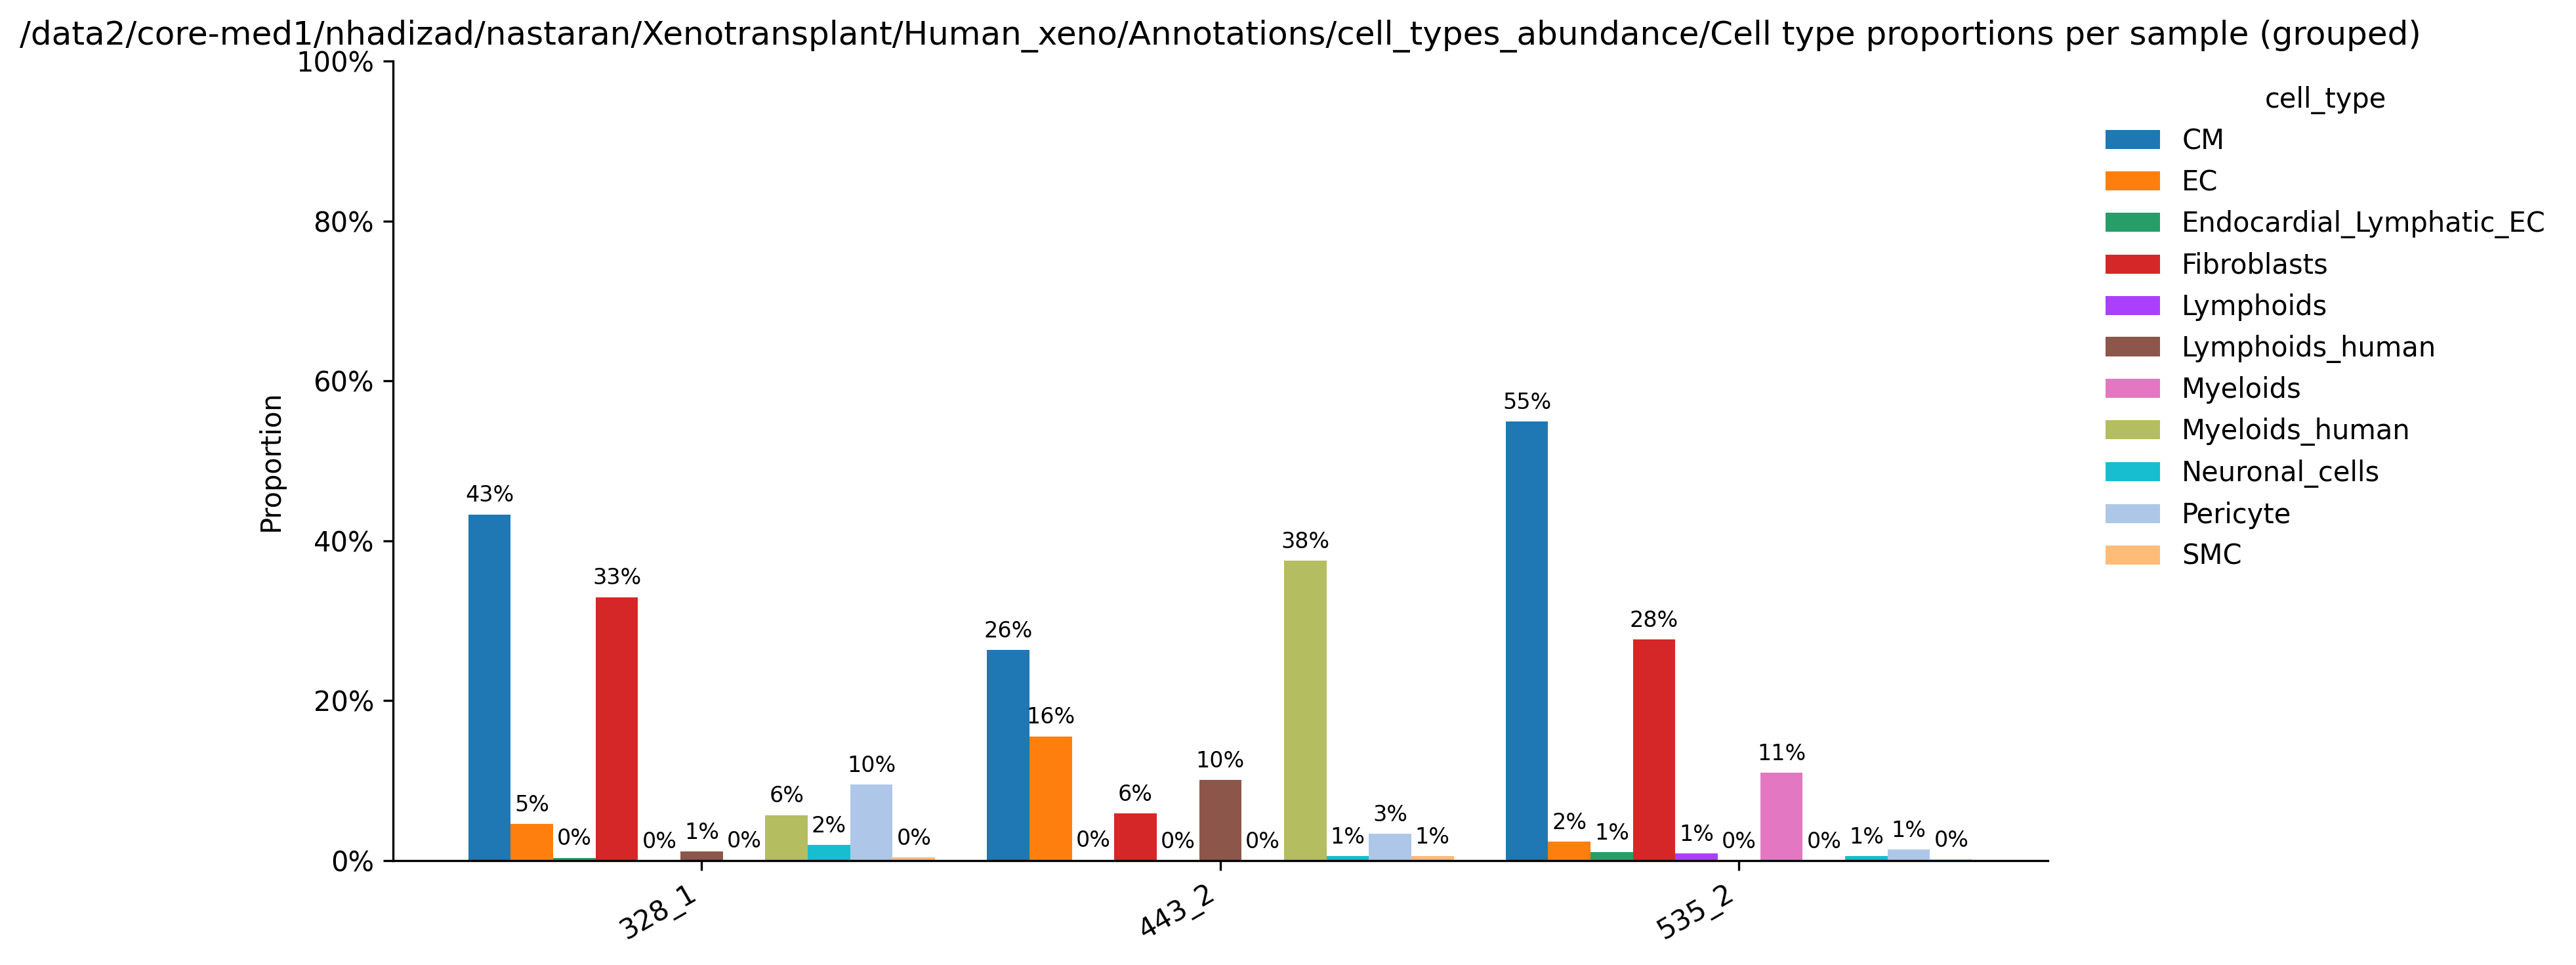

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

# --- Config (edit if your keys differ) ---
sample_key = 'sample'
celltype_key = 'cell_type'

# --- Pull columns and clean ---
obs = global_human.obs[[sample_key, celltype_key]].copy()
obs = obs.dropna(subset=[sample_key, celltype_key])

# --- Preserve category order if present; otherwise set a sensible order ---
if pd.api.types.is_categorical_dtype(obs[celltype_key]):
    celltype_order = list(obs[celltype_key].cat.categories)
else:
    celltype_order = sorted(obs[celltype_key].unique())

if pd.api.types.is_categorical_dtype(obs[sample_key]):
    sample_order = list(obs[sample_key].cat.categories)
else:
    sample_order = list(pd.unique(obs[sample_key]))  # or: sorted(obs[sample_key].unique())

# --- Build wide counts and proportions ---
counts = (
    obs.groupby([sample_key, celltype_key])
       .size()
       .unstack(fill_value=0)
       .reindex(index=sample_order, columns=celltype_order, fill_value=0)
)
props = counts.div(counts.sum(axis=1), axis=0).fillna(0)

# --- Colors: use AnnData palette if aligned with categorical order; otherwise fallback ---
if ('cell_type_colors' in global_human.uns
    and pd.api.types.is_categorical_dtype(global_human.obs[celltype_key])
    and len(global_human.uns['cell_type_colors']) >= len(celltype_order)):
    color_list = [global_human.uns['cell_type_colors'][i] for i, _ in enumerate(celltype_order)]
else:
    import matplotlib.cm as cm
    cmap = cm.get_cmap('tab20', len(celltype_order))
    color_list = [cmap(i) for i in range(len(celltype_order))]

color_map = dict(zip(celltype_order, color_list))

# --- Long (tidy) table for export/inspection ---
props_long = (
    props.reset_index()
         .melt(id_vars=sample_key, var_name=celltype_key, value_name='proportion')
)
props_long[celltype_key] = pd.Categorical(props_long[celltype_key], categories=celltype_order, ordered=True)
props_long[sample_key] = pd.Categorical(props_long[sample_key], categories=sample_order, ordered=True)
props_long = props_long.sort_values([sample_key, celltype_key])

# --- Grouped bar plot (side-by-side) with % annotations only ---
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['savefig.dpi'] = 300

n_samples = len(sample_order)
n_types = len(celltype_order)
group_width = 0.9
bar_w = group_width / n_types

fig_w = max(12, 0.6 * n_samples)   # widen with number of samples
fig, ax = plt.subplots(figsize=(fig_w, 5), dpi=300)

x_centers = np.arange(n_samples)

for j, ct in enumerate(celltype_order):
    y = props[ct].values
    x = x_centers - group_width/2 + j*bar_w + bar_w/2
    bars = ax.bar(x, y, width=bar_w, color=color_map[ct], label=ct, linewidth=0)

    # annotate each bar with "XX%"
    for b in bars:
        height = b.get_height()
        txt = f"{height*100:.0f}%"
        voff = 0.01 if height < 0.9 else 0.005  # small offset above the bar
        y_text = min(1.0, height + voff)
        ax.annotate(
            txt,
            xy=(b.get_x() + b.get_width()/2, y_text),
            ha='center', va='bottom',
            fontsize=8,
            clip_on=False
        )

ax.set_xticks(x_centers)
ax.set_xticklabels(sample_order, rotation=30, ha='right')
ax.set_ylabel('Proportion')
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_title('/data2/core-med1/nhadizad/nastaran/Xenotransplant/Human_xeno/Annotations/cell_types_abundance/Cell type proportions per sample (grouped)')
ax.legend(title='cell_type', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False, ncol=1)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()

# --- Save outputs ---
plt.savefig('/data2/core-med1/nhadizad/nastaran/Xenotransplant/Human_xeno/Annotations/cell_types_abundance/cell_type_proportions_per_sample_grouped_percent_only.pdf', dpi=300)
props.to_csv('/data2/core-med1/nhadizad/nastaran/Xenotransplant/Human_xeno/Annotations/cell_types_abundance/cell_type_proportions_per_sample_wide.csv')
props_long.to_csv('/data2/core-med1/nhadizad/nastaran/Xenotransplant/Human_xeno/Annotations/cell_types_abundance/cell_type_proportions_per_sample_long.csv', index=False)


Saved long CSV with columns [sample, cell_type, count, proportion, percentage]: /data2/core-med1/nhadizad/nastaran/Xenotransplant/Human_xeno/Annotations/cell_types_abundance/cell_type_abundance_and_proportions_per_sample_LONG.csv


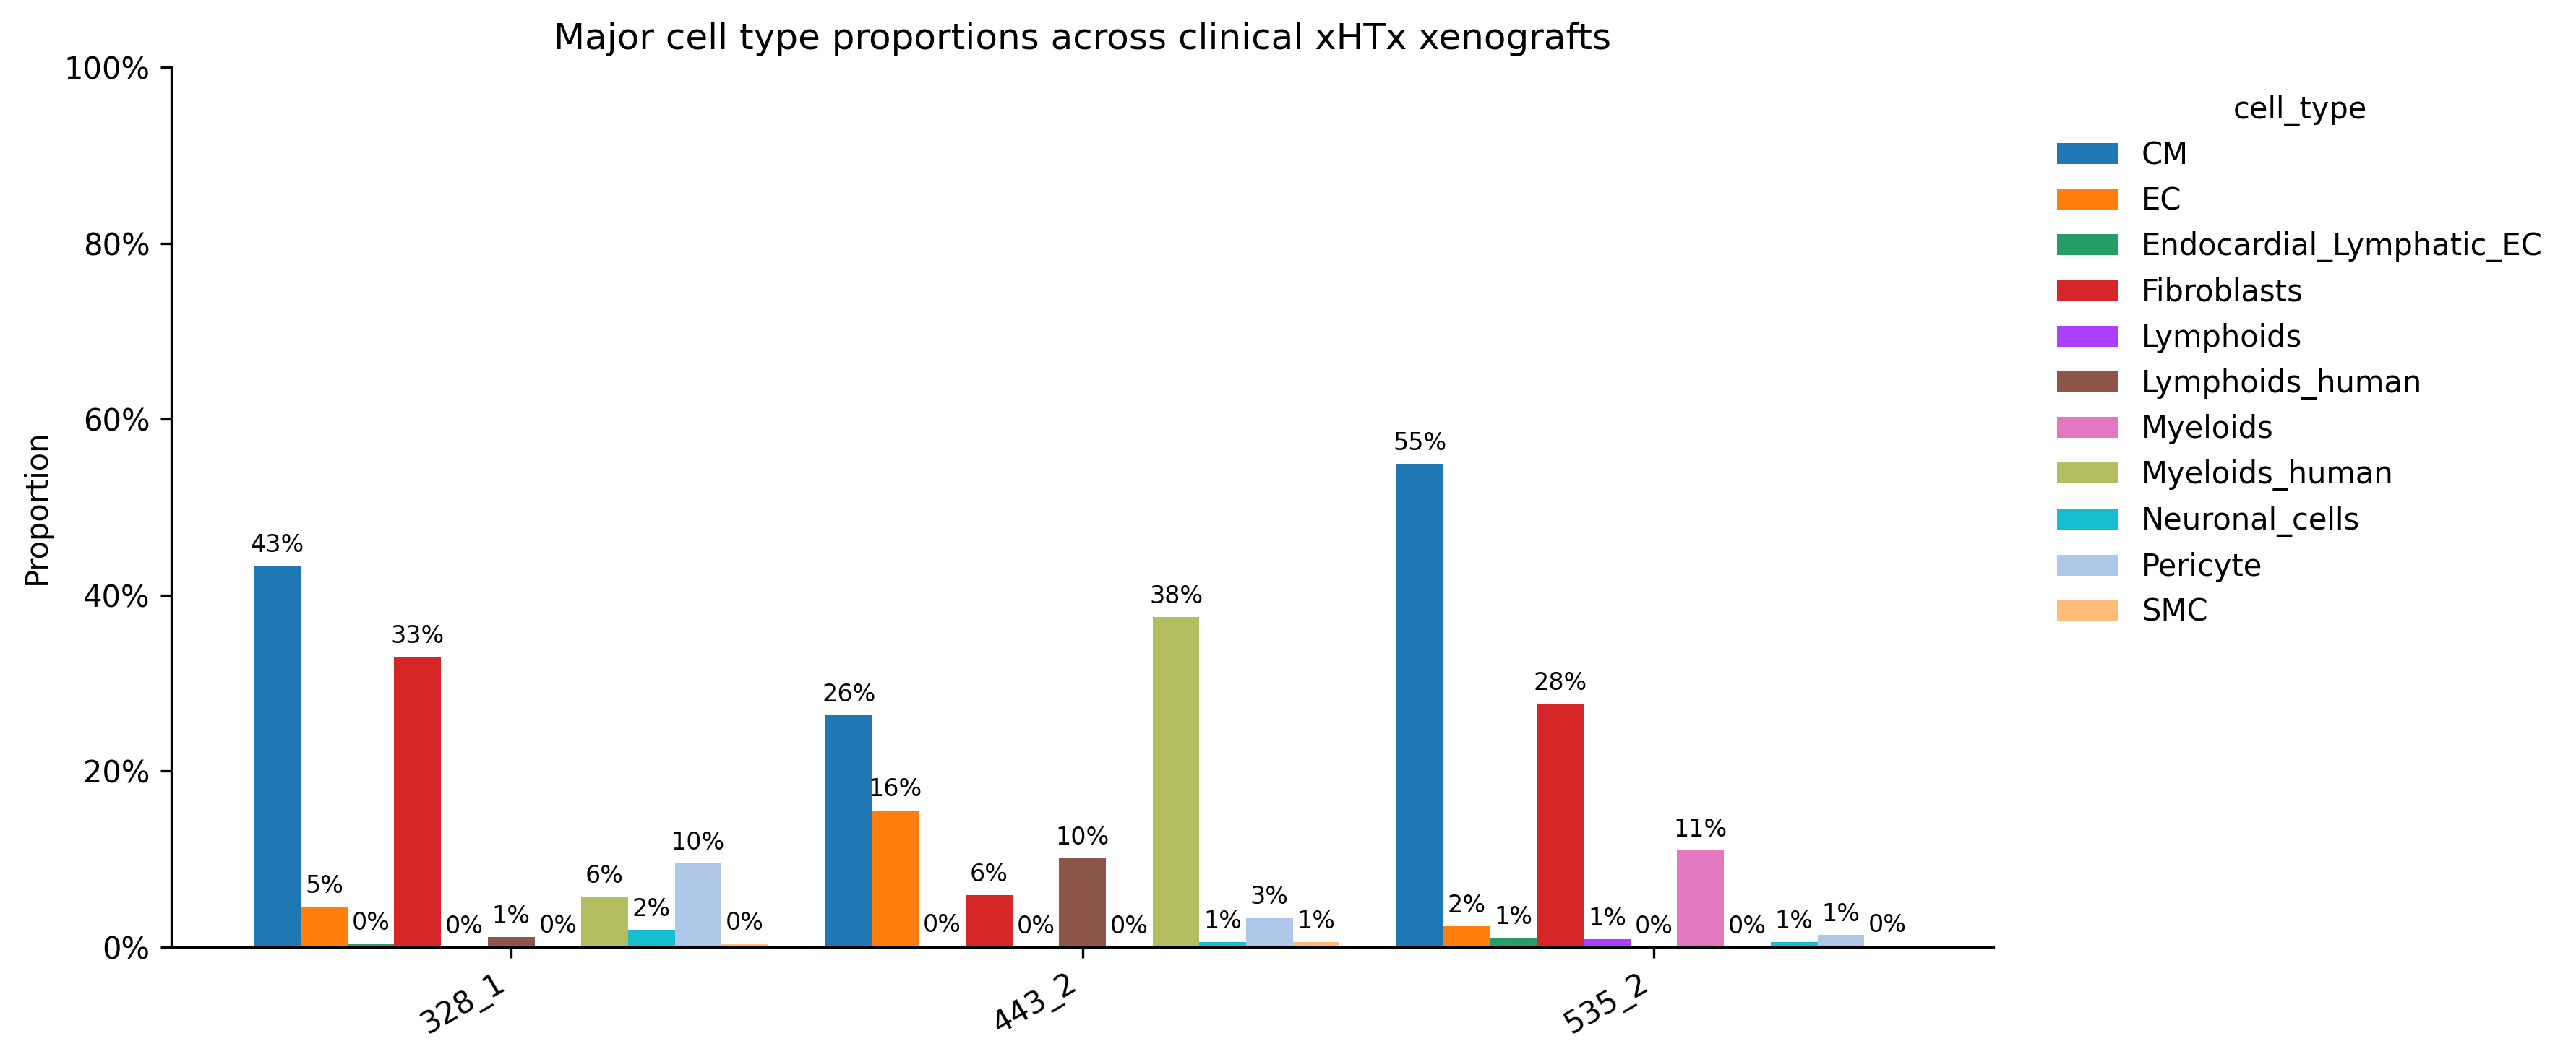

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

# --- Config (edit if your keys differ) ---
sample_key = 'sample'
celltype_key = 'cell_type'

# --- Pull columns and clean ---
obs = global_human.obs[[sample_key, celltype_key]].copy()
obs = obs.dropna(subset=[sample_key, celltype_key])

# --- Preserve category order if present; otherwise set a sensible order ---
if pd.api.types.is_categorical_dtype(obs[celltype_key]):
    celltype_order = list(obs[celltype_key].cat.categories)
else:
    celltype_order = sorted(obs[celltype_key].unique())

if pd.api.types.is_categorical_dtype(obs[sample_key]):
    sample_order = list(obs[sample_key].cat.categories)
else:
    sample_order = list(pd.unique(obs[sample_key]))  # or: sorted(obs[sample_key].unique())

# --- Build wide counts and proportions ---
counts = (
    obs.groupby([sample_key, celltype_key])
       .size()
       .unstack(fill_value=0)
       .reindex(index=sample_order, columns=celltype_order, fill_value=0)
)

row_sums = counts.sum(axis=1).replace(0, np.nan)
props = counts.div(row_sums, axis=0).fillna(0)

# --- Colors: use AnnData palette if aligned with categorical order; otherwise fallback ---
if ('cell_type_colors' in global_human.uns
    and pd.api.types.is_categorical_dtype(global_human.obs[celltype_key])
    and len(global_human.uns['cell_type_colors']) >= len(celltype_order)):
    color_list = [global_human.uns['cell_type_colors'][i] for i, _ in enumerate(celltype_order)]
else:
    import matplotlib.cm as cm
    cmap = cm.get_cmap('tab20', len(celltype_order))
    color_list = [cmap(i) for i in range(len(celltype_order))]

color_map = dict(zip(celltype_order, color_list))

# --- Long (tidy) table with count + proportion + percentage ---
# counts_long
counts_long = (
    counts.reset_index()
          .melt(id_vars=sample_key, var_name=celltype_key, value_name='count')
)
# props_long
props_long = (
    props.reset_index()
         .melt(id_vars=sample_key, var_name=celltype_key, value_name='proportion')
)

# merge and add percentage
long_df = pd.merge(counts_long, props_long, on=[sample_key, celltype_key], how='left')
long_df['percentage'] = long_df['proportion'] * 100.0

# enforce ordering & sort
long_df[celltype_key] = pd.Categorical(long_df[celltype_key], categories=celltype_order, ordered=True)
long_df[sample_key]   = pd.Categorical(long_df[sample_key],   categories=sample_order,   ordered=True)
long_df = long_df.sort_values([sample_key, celltype_key])

# --- Grouped bar plot (side-by-side) with % annotations only ---
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['savefig.dpi'] = 300

n_samples = len(sample_order)
n_types = len(celltype_order)
group_width = 0.9
bar_w = group_width / n_types

fig_w = max(12, 0.6 * n_samples)   # widen with number of samples
fig, ax = plt.subplots(figsize=(fig_w, 5), dpi=300)

x_centers = np.arange(n_samples)

for j, ct in enumerate(celltype_order):
    y = props[ct].values
    x = x_centers - group_width/2 + j*bar_w + bar_w/2
    bars = ax.bar(x, y, width=bar_w, color=color_map[ct], label=ct, linewidth=0)

    # annotate each bar with "XX%"
    for b in bars:
        height = b.get_height()
        txt = f"{height*100:.0f}%"
        voff = 0.01 if height < 0.9 else 0.005  # small offset above the bar
        y_text = min(1.0, height + voff)
        ax.annotate(
            txt,
            xy=(b.get_x() + b.get_width()/2, y_text),
            ha='center', va='bottom',
            fontsize=8,
            clip_on=False
        )

ax.set_xticks(x_centers)
ax.set_xticklabels(sample_order, rotation=30, ha='right')
ax.set_ylabel('Proportion')
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_title('Major cell type proportions across clinical xHTx xenografts')
ax.legend(title='cell_type', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False, ncol=1)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()

# --- Save outputs ---
plt.savefig('/data2/core-med1/nhadizad/nastaran/Xenotransplant/Human_xeno/Annotations/cell_types_abundance/cell_type_proportions_per_sample_grouped_percent_only.pdf', dpi=300)

# single long CSV with the exact columns you requested
long_out = '/data2/core-med1/nhadizad/nastaran/Xenotransplant/Human_xeno/Annotations/cell_types_abundance/cell_type_abundance_and_proportions_per_sample_LONG.csv'
long_df[['sample','cell_type','count','proportion','percentage']].to_csv(long_out, index=False)

print(f"Saved long CSV with columns [sample, cell_type, count, proportion, percentage]: {long_out}")
